In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import math

For the final project, we want to examine whether the energy dissipations due to the collisions between the different balls are linear. The formula for potential energy of an object at certain height above the point where energy is defined to be 0 is
\begin{align*}
U(h) = mgh.
\end{align*}
After a ball contact with another ball, creating a cascade in the Newton's Cradle, we saw that the resultant ball doesn't come up as high as it initially started. Therefore, we deduce that some energy was loss due to the collision between the different balls. When we graph the different rate of energy loss, we want to see whether this loss is linear or not for different number of collisions and also for different number of balls.

In [10]:
data1 = pd.read_csv("data/1 ball drop 1 ball cascade.csv")
data1 = data1.rename(columns={'VideoAnalysis: Time (s)':'Number of collisions'})
data1["Number of collisions"] = [0,1,2,3,4,5,6,7,8]
data1 = data1.assign(dY = [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001])
data1

,Number of collisions,VideoAnalysis: X (m),VideoAnalysis: Y (m),VideoAnalysis: X Velocity (m/s),VideoAnalysis: Y Velocity (m/s),dY
0,0,0.460747,0.180349,0.269099,-0.002099,0.001
1,1,0.728375,0.178802,0.055811,-0.001234,0.001
2,2,0.463841,0.178802,0.016191,-0.000705,0.001
3,3,0.727601,0.178029,0.000358,-0.000033,0.001
4,4,0.464615,0.179576,-0.000183,-0.000642,0.001
5,5,0.726828,0.176482,0.000315,-0.000157,0.001
6,6,0.465388,0.179576,-0.015850,0.000128,0.001
7,7,0.726828,0.177255,-0.054340,-0.000500,0.001
8,8,0.465388,0.178029,-0.269722,0.000409,0.001


In [12]:
def linear_model(x, A, B):
    y = A + B*x
    return y

In [14]:
fit_param, fit_param_errors = opt.curve_fit(linear_model,  
                                            data1["Number of collisions"],  
                                            data1["VideoAnalysis: Y (m)"],  
                                            sigma=data1["dY"],
                                            absolute_sigma=True )
intercept_1 = fit_param[0]
d_intercept_1 = np.sqrt(fit_param_errors[0,0])   


slope_1 = fit_param[1]
d_slope_1 = np.sqrt(fit_param_errors[1,1])
print(f"Intercept 1 = {intercept_1}, d Intercept 1 = {d_intercept_1}")
print(f"Slope 1 = {slope_1}, d_slope 1 = {slope_1}")

Intercept 1 = 0.17947237082032153, d Intercept 1 = 0.0006146362416692575
Slope 1 = -0.00023204706926516216, d_slope 1 = -0.00023204706926516216


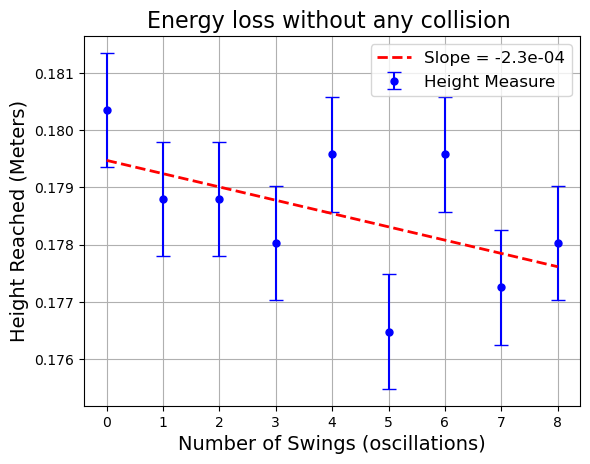

In [153]:
plt.errorbar(data1["Number of collisions"], data1["VideoAnalysis: Y (m)"], 
             yerr=data1["dY"], fmt='o', c = "blue",
             label='Height Measure', markersize=5, capsize=5)

# Model plot
plt.plot(data1["Number of collisions"], 
         linear_model(data1["Number of collisions"], intercept_1, slope_1), 
         color='red', linestyle='--', label=f'Slope = {slope_1:.1e}', linewidth=2)

# Title and labels
plt.title("Energy loss without any collision ", fontsize=16)
plt.xlabel("Number of Swings (oscillations)", fontsize=14)
plt.ylabel("Height Reached (Meters)", fontsize=14)

# Legend
plt.legend(fontsize=12, loc = "upper right")
plt.grid(True)
# Save the plot in high resolution
plt.savefig("energy_lost_plot.png")
# Show the plot
plt.show()



In [17]:
data2 = pd.read_csv("data/1 ball drop 2 balls cascade.csv")
data2 = data2.rename(columns={'VideoAnalysis: Time (s)':'Number of collisions'})
data2["Number of collisions"] = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]
data2 = data2.assign(dY = [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,0.001,0.001,0.001,0.001,0.001,0.001, 0.001])
data2

,Number of collisions,VideoAnalysis: X (m),VideoAnalysis: Y (m),VideoAnalysis: X Velocity (m/s),VideoAnalysis: Y Velocity (m/s),dY
0,0,0.737963,0.187559,-0.216793,-0.006389,0.001
1,1,0.390749,0.180646,-0.031839,-0.004039,0.001
2,2,0.724136,0.179109,-0.003918,-0.001112,0.001
3,3,0.398430,0.177573,-0.000257,-0.000617,0.001
4,4,0.718759,0.175268,0.000232,-0.000457,0.001
5,5,0.403808,0.173732,-0.000204,-0.000396,0.001
6,6,0.713381,0.171427,0.000209,-0.000267,0.001
7,7,0.409185,0.171427,-0.000208,-0.000137,0.001
8,8,0.708772,0.170659,0.000030,-0.000098,0.001
9,9,0.411489,0.170659,-0.000237,-0.000103,0.001


In [18]:
fit_param, fit_param_errors = opt.curve_fit(linear_model,  
                                            data2["Number of collisions"],  
                                            data2["VideoAnalysis: Y (m)"],  
                                            sigma=data2["dY"],
                                            absolute_sigma=True )
intercept_2 = fit_param[0]
d_intercept_2 = np.sqrt(fit_param_errors[0,0])   


slope_2 = fit_param[1]
d_slope_2 = np.sqrt(fit_param_errors[1,1])
print(f"Intercept 2 = {intercept_2}, d Intercept 2 = {d_intercept_2}")
print(f"Slope 2 = {slope_2}, d_slope 2 = {slope_2}")

Intercept 2 = 0.18148902563221425, d Intercept 2 = 0.0004644203705798694
Slope 2 = -0.0011616732601618107, d_slope 2 = -0.0011616732601618107


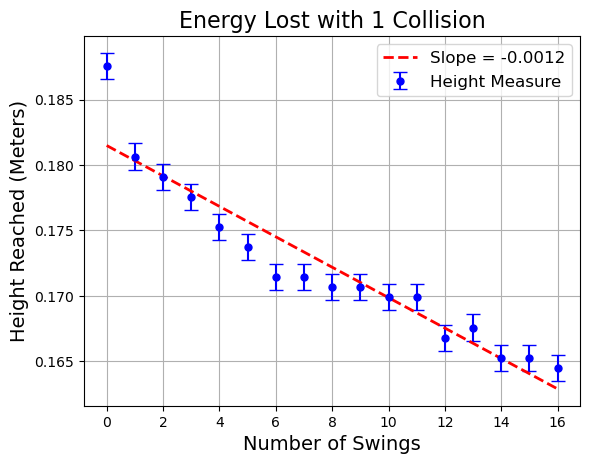

In [19]:
# Error bar plot
plt.errorbar(data2["Number of collisions"], data2["VideoAnalysis: Y (m)"], 
             yerr=data2["dY"], fmt='o', color='blue', 
             label='Height Measure', markersize=5, capsize=5)

# Model plot
plt.plot(data2["Number of collisions"], 
         linear_model(data2["Number of collisions"], intercept_2, slope_2), 
         color='red', linestyle='--', label=f'Slope = {slope_2:.2g}', linewidth=2)

# Title and labels
plt.title("Energy Lost with 1 Collision", fontsize=16)
plt.xlabel("Number of Swings", fontsize=14)
plt.ylabel("Height Reached (Meters)", fontsize=14)

# Legend
plt.legend(fontsize=12, loc='upper right')

# Grid
plt.grid(True)

# Save the plot in high resolution
plt.savefig("energy_lost_plot_2.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [20]:
data3 = pd.read_csv("data/1 ball drop 3 balls cascade.csv")
data3 = data3.rename(columns={'VideoAnalysis: Time (s)':'Number of collisions'})
data3["Number of collisions"] = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23]
data3 = data3.assign(dY = [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,0.001,0.001,0.001,0.001,0.001,0.001, 0.001,0.001 ,0.001,0.001,0.001,0.001,0.001,0.001])
data3

,Number of collisions,VideoAnalysis: X (m),VideoAnalysis: Y (m),VideoAnalysis: X Velocity (m/s),VideoAnalysis: Y Velocity (m/s),dY
0,0,0.427253,0.202224,0.402625,-0.010606,0.001
1,1,0.841403,0.192934,0.027787,-0.003185,0.001
2,2,0.431123,0.196805,0.004752,-0.000700,0.001
3,3,0.838306,0.191386,0.000017,-0.000542,0.001
4,4,0.433445,0.192160,-0.000305,-0.000473,0.001
5,5,0.832888,0.186741,0.000069,-0.000338,0.001
6,6,0.437316,0.189838,-0.000290,-0.000344,0.001
7,7,0.826695,0.183645,0.000180,-0.000328,0.001
8,8,0.442735,0.187515,-0.000241,-0.000416,0.001
9,9,0.820502,0.179000,0.000255,-0.000300,0.001


In [21]:
fit_param, fit_param_errors = opt.curve_fit(linear_model,  
                                            data3["Number of collisions"],  
                                            data3["VideoAnalysis: Y (m)"],  
                                            sigma=data3["dY"],
                                            absolute_sigma=True )
intercept_3 = fit_param[0]
d_intercept_3 = np.sqrt(fit_param_errors[0,0])   


slope_3 = fit_param[1]
d_slope_3 = np.sqrt(fit_param_errors[1,1])
print(f"Intercept 3 = {intercept_3}, d Intercept 3 = {d_intercept_3}")
print(f"Slope 3 = {slope_3} d_slope 3 = {slope_3}")

Intercept 3 = 0.19670418549164742, d Intercept 3 = 0.00039581140549422715
Slope 3 = -0.001413260821076221 d_slope 3 = -0.001413260821076221


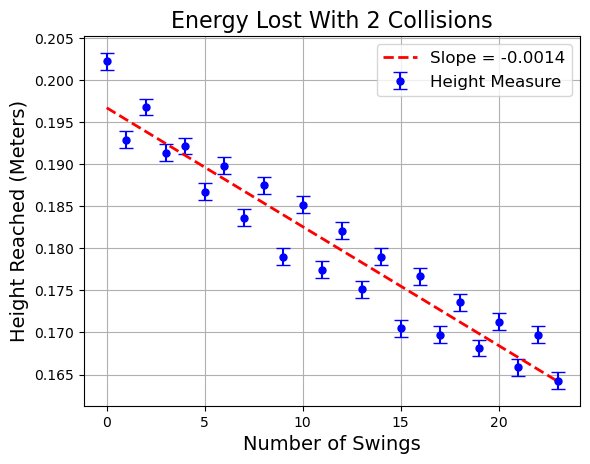

In [22]:
# Error bar plot
plt.errorbar(data3["Number of collisions"], data3["VideoAnalysis: Y (m)"], 
             yerr=data3["dY"], fmt='o', color='blue', 
             label='Height Measure', markersize=5, capsize=5)

# Model plot
plt.plot(data3["Number of collisions"], 
         linear_model(data3["Number of collisions"], intercept_3, slope_3), 
         color='red', linestyle='--', label=f'Slope = {slope_3:.2g}', linewidth=2)

# Title and labels
plt.title("Energy Lost With 2 Collisions", fontsize=16)
plt.xlabel("Number of Swings", fontsize=14)
plt.ylabel("Height Reached (Meters)", fontsize=14)

# Legend
plt.legend(fontsize=12, loc='upper right')

# Grid
plt.grid(True)

# Save the plot in high resolution
plt.savefig("energy_lost_plot_3.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [23]:
data4 = pd.read_csv("data/1 ball drop 4 balls cascade.csv")
data4 = data4.rename(columns={'VideoAnalysis: Time (s)':'Number of collisions'})
data4["Number of collisions"] = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18]
data4 = data4.assign(dY = [0.001, 0.001, 0.001, 0.001, 0.001,0.001,0.001,0.001,0.001,0.001,0.001, 0.001,0.001 ,0.001,0.001,0.001,0.001,0.001,0.001])
data4

,Number of collisions,VideoAnalysis: X (m),VideoAnalysis: Y (m),VideoAnalysis: X Velocity (m/s),VideoAnalysis: Y Velocity (m/s),dY
0,0,0.308840,0.221523,0.430278,-0.014814,0.001
1,1,0.864467,0.206231,0.103018,-0.008430,0.001
2,2,0.319035,0.213027,0.004988,-0.005914,0.001
3,3,0.849174,0.197735,0.001048,-0.002682,0.001
4,4,0.328381,0.202832,-0.004026,-0.001021,0.001
5,5,0.841528,0.193487,-0.004321,-0.000934,0.001
6,6,0.339425,0.193487,-0.013882,-0.000681,0.001
7,7,0.352169,0.187540,0.013237,-0.000891,0.001
8,8,0.815191,0.178195,0.005074,-0.000621,0.001
9,9,0.360665,0.183292,0.002345,-0.000532,0.001


In [24]:
fit_param, fit_param_errors = opt.curve_fit(linear_model,  
                                            data4["Number of collisions"],  
                                            data4["VideoAnalysis: Y (m)"],  
                                            sigma=data4["dY"],
                                            absolute_sigma=True )
intercept_4 = fit_param[0]
d_intercept_4 = np.sqrt(fit_param_errors[0,0])   


slope_4 = fit_param[1]
d_slope_4 = np.sqrt(fit_param_errors[1,1])
print(f"Intercept 4 = {intercept_4}, d Intercept 4 = {d_intercept_4}")
print(f"Slope 4 = {slope_4}, d_slope 4 = {slope_4}")

Intercept 4 = 0.2118335584990645, d Intercept 4 = 0.0004412899746501714
Slope 4 = -0.003086815595596759, d_slope 4 = -0.003086815595596759


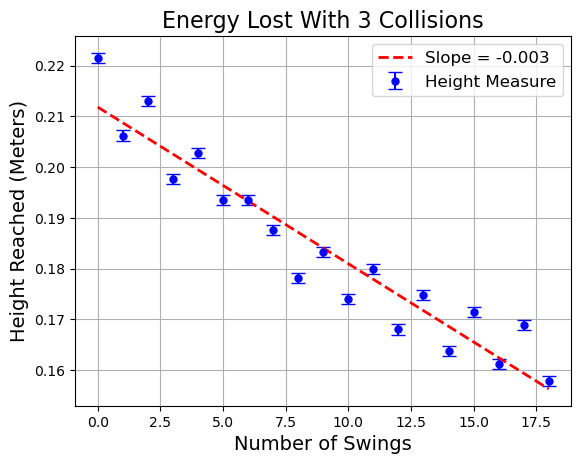

In [25]:
# Error bar plot
plt.errorbar(data4["Number of collisions"], data4["VideoAnalysis: Y (m)"], 
             yerr=data4["dY"], fmt='o', color='blue', 
             label='Height Measure', markersize=5, capsize=5)

# Model plot
plt.plot(data4["Number of collisions"], 
         linear_model(data4["Number of collisions"], intercept_4, slope_4), 
         color='red', linestyle='--', label=f'Slope = {slope_4:.1g}', linewidth=2)

# Title and labels
plt.title("Energy Lost With 3 Collisions", fontsize=16)
plt.xlabel("Number of Swings", fontsize=14)
plt.ylabel("Height Reached (Meters)", fontsize=14)

# Legend
plt.legend(fontsize=12, loc='upper right')

# Grid
plt.grid(True)

# Save the plot in high resolution
plt.savefig("energy_lost_plot_4.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [27]:
data5 = pd.read_csv("data/1 ball 5 balls cascade.csv")
data5 = data5.rename(columns={'VideoAnalysis: Time (s)':'Number of collisions'})
data5["Number of collisions"] = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18]
data5 = data5.assign(dY = [0.001, 0.001, 0.001, 0.001, 0.001,0.001,0.001,0.001,0.001,0.001,0.001, 0.001,0.001 ,0.001,0.001,0.001,0.001,0.001,0.001])
data5

,Number of collisions,VideoAnalysis: X (m),VideoAnalysis: Y (m),VideoAnalysis: X Velocity (m/s),VideoAnalysis: Y Velocity (m/s),dY
0,0,0.315995,0.223683,0.071082,-0.002743,0.001
1,1,0.931358,0.204209,0.015655,-0.001436,0.001
2,2,0.330795,0.211219,0.004245,-0.000886,0.001
3,3,0.921231,0.198756,0.000280,-0.000753,0.001
4,4,0.339363,0.204988,-0.000520,-0.000771,0.001
5,5,0.909547,0.191746,0.000301,-0.000780,0.001
6,6,0.347931,0.197977,-0.000221,-0.000769,0.001
7,7,0.902537,0.184735,0.000435,-0.000717,0.001
8,8,0.358058,0.191746,-0.000397,-0.000640,0.001
9,9,0.892411,0.179283,0.000280,-0.000578,0.001


In [29]:
fit_param, fit_param_errors = opt.curve_fit(linear_model,  
                                            data5["Number of collisions"],  
                                            data5["VideoAnalysis: Y (m)"],  
                                            sigma=data5["dY"],
                                            absolute_sigma=True )
intercept_5 = fit_param[0]
d_intercept_5 = np.sqrt(fit_param_errors[0,0])   


slope_5 = fit_param[1]
d_slope_5 = np.sqrt(fit_param_errors[1,1])
print(f"Intercept 5= {intercept_5}, d Intercept 5 = {d_intercept_5}")
print(f"Slope 5 = {slope_5}, d_slope 5 = {slope_5}")

Intercept 5= 0.21071110781893296, d Intercept 5 = 0.0004412899765034188
Slope 5 = -0.0025308725747570514, d_slope 5 = -0.0025308725747570514


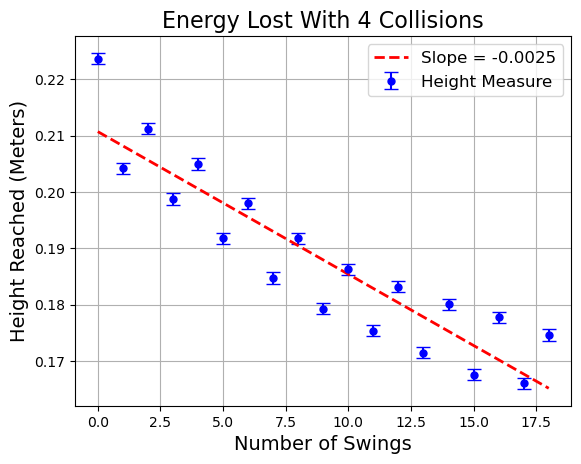

In [30]:
# Error bar plot
plt.errorbar(data5["Number of collisions"], data5["VideoAnalysis: Y (m)"], 
             yerr=data5["dY"], fmt='o', color='blue', 
             label='Height Measure', markersize=5, capsize=5)

# Model plot
plt.plot(data5["Number of collisions"], 
         linear_model(data5["Number of collisions"], intercept_5, slope_5), 
         color='red', linestyle='--', label=f'Slope = {slope_5:.2g}', linewidth=2)

# Title and labels
plt.title("Energy Lost With 4 Collisions", fontsize=16)
plt.xlabel("Number of Swings", fontsize=14)
plt.ylabel("Height Reached (Meters)", fontsize=14)

# Legend
plt.legend(fontsize=12, loc='upper right')

# Grid
plt.grid(True)

# Save the plot in high resolution
plt.savefig("energy_lost_plot_5.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

num_pendulum = np.arange(1, 6); 
slopes = np.array([slope_1, slope_2, slope_3, slope_4, slope_5])
errors = np.array([d_slope_1, d_slope_2, d_slope_3, d_slope_4, d_slope_5])

In [31]:
fit_param, fit_param_errors = opt.curve_fit(linear_model,  
                                            num_pendulum,  
                                            slopes,  
                                            sigma=errors,
                                            absolute_sigma=True )

intercept_final = fit_param[0]
d_intercept_final = np.sqrt(fit_param_errors[0,0])   


slope_final = fit_param[1]
d_slope_final = np.sqrt(fit_param_errors[1,1])
print(f"Intercept final = {intercept_final}, d Intercept final = {d_intercept_final}")
print(f"Slope final = {slope_final}, d_slope final = {d_slope_final}")

Intercept final = 0.00021024515861670345, d Intercept final = 6.55146953466134e-05
Slope final = -0.000623421514059312, d_slope final = 1.828355435587068e-05


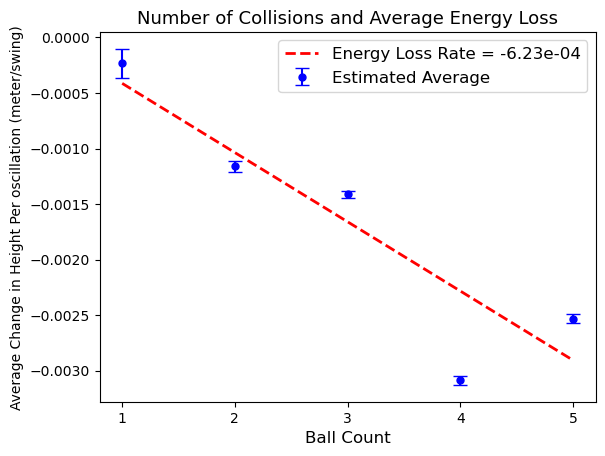

<Figure size 1000x200 with 0 Axes>

In [115]:
# Error bar plot
plt.errorbar(num_pendulum, slopes, 
             yerr=errors, fmt='o', color='blue', 
             label='Estimated Average', markersize=5, capsize=5)

# Model plot
plt.plot(num_pendulum, 
         linear_model(num_pendulum, intercept_final, slope_final), 
         color='red', linestyle='--', label=f'Energy Loss Rate = {slope_final:.2e}', linewidth=2)

plt.xticks(ticks=np.arange(1 ,6))

# Title and labels
plt.title("Number of Collisions and Average Energy Loss", fontsize=13)
plt.xlabel("Ball Count", fontsize=12)
plt.ylabel("Average Change in Height Per oscillation (meter/swing)", fontsize=10)

# Legend
plt.legend(fontsize=12, loc='upper right')

# Grid
plt.grid(False)

# Save the plot in high resolution
plt.savefig("pendulum_slope_plot.png", dpi=300, bbox_inches='tight')
plt.figure(figsize=(10, 2))

# Show the plot
plt.show()


The slope of the line is
\begin{align*}
m = 
\end{align*}

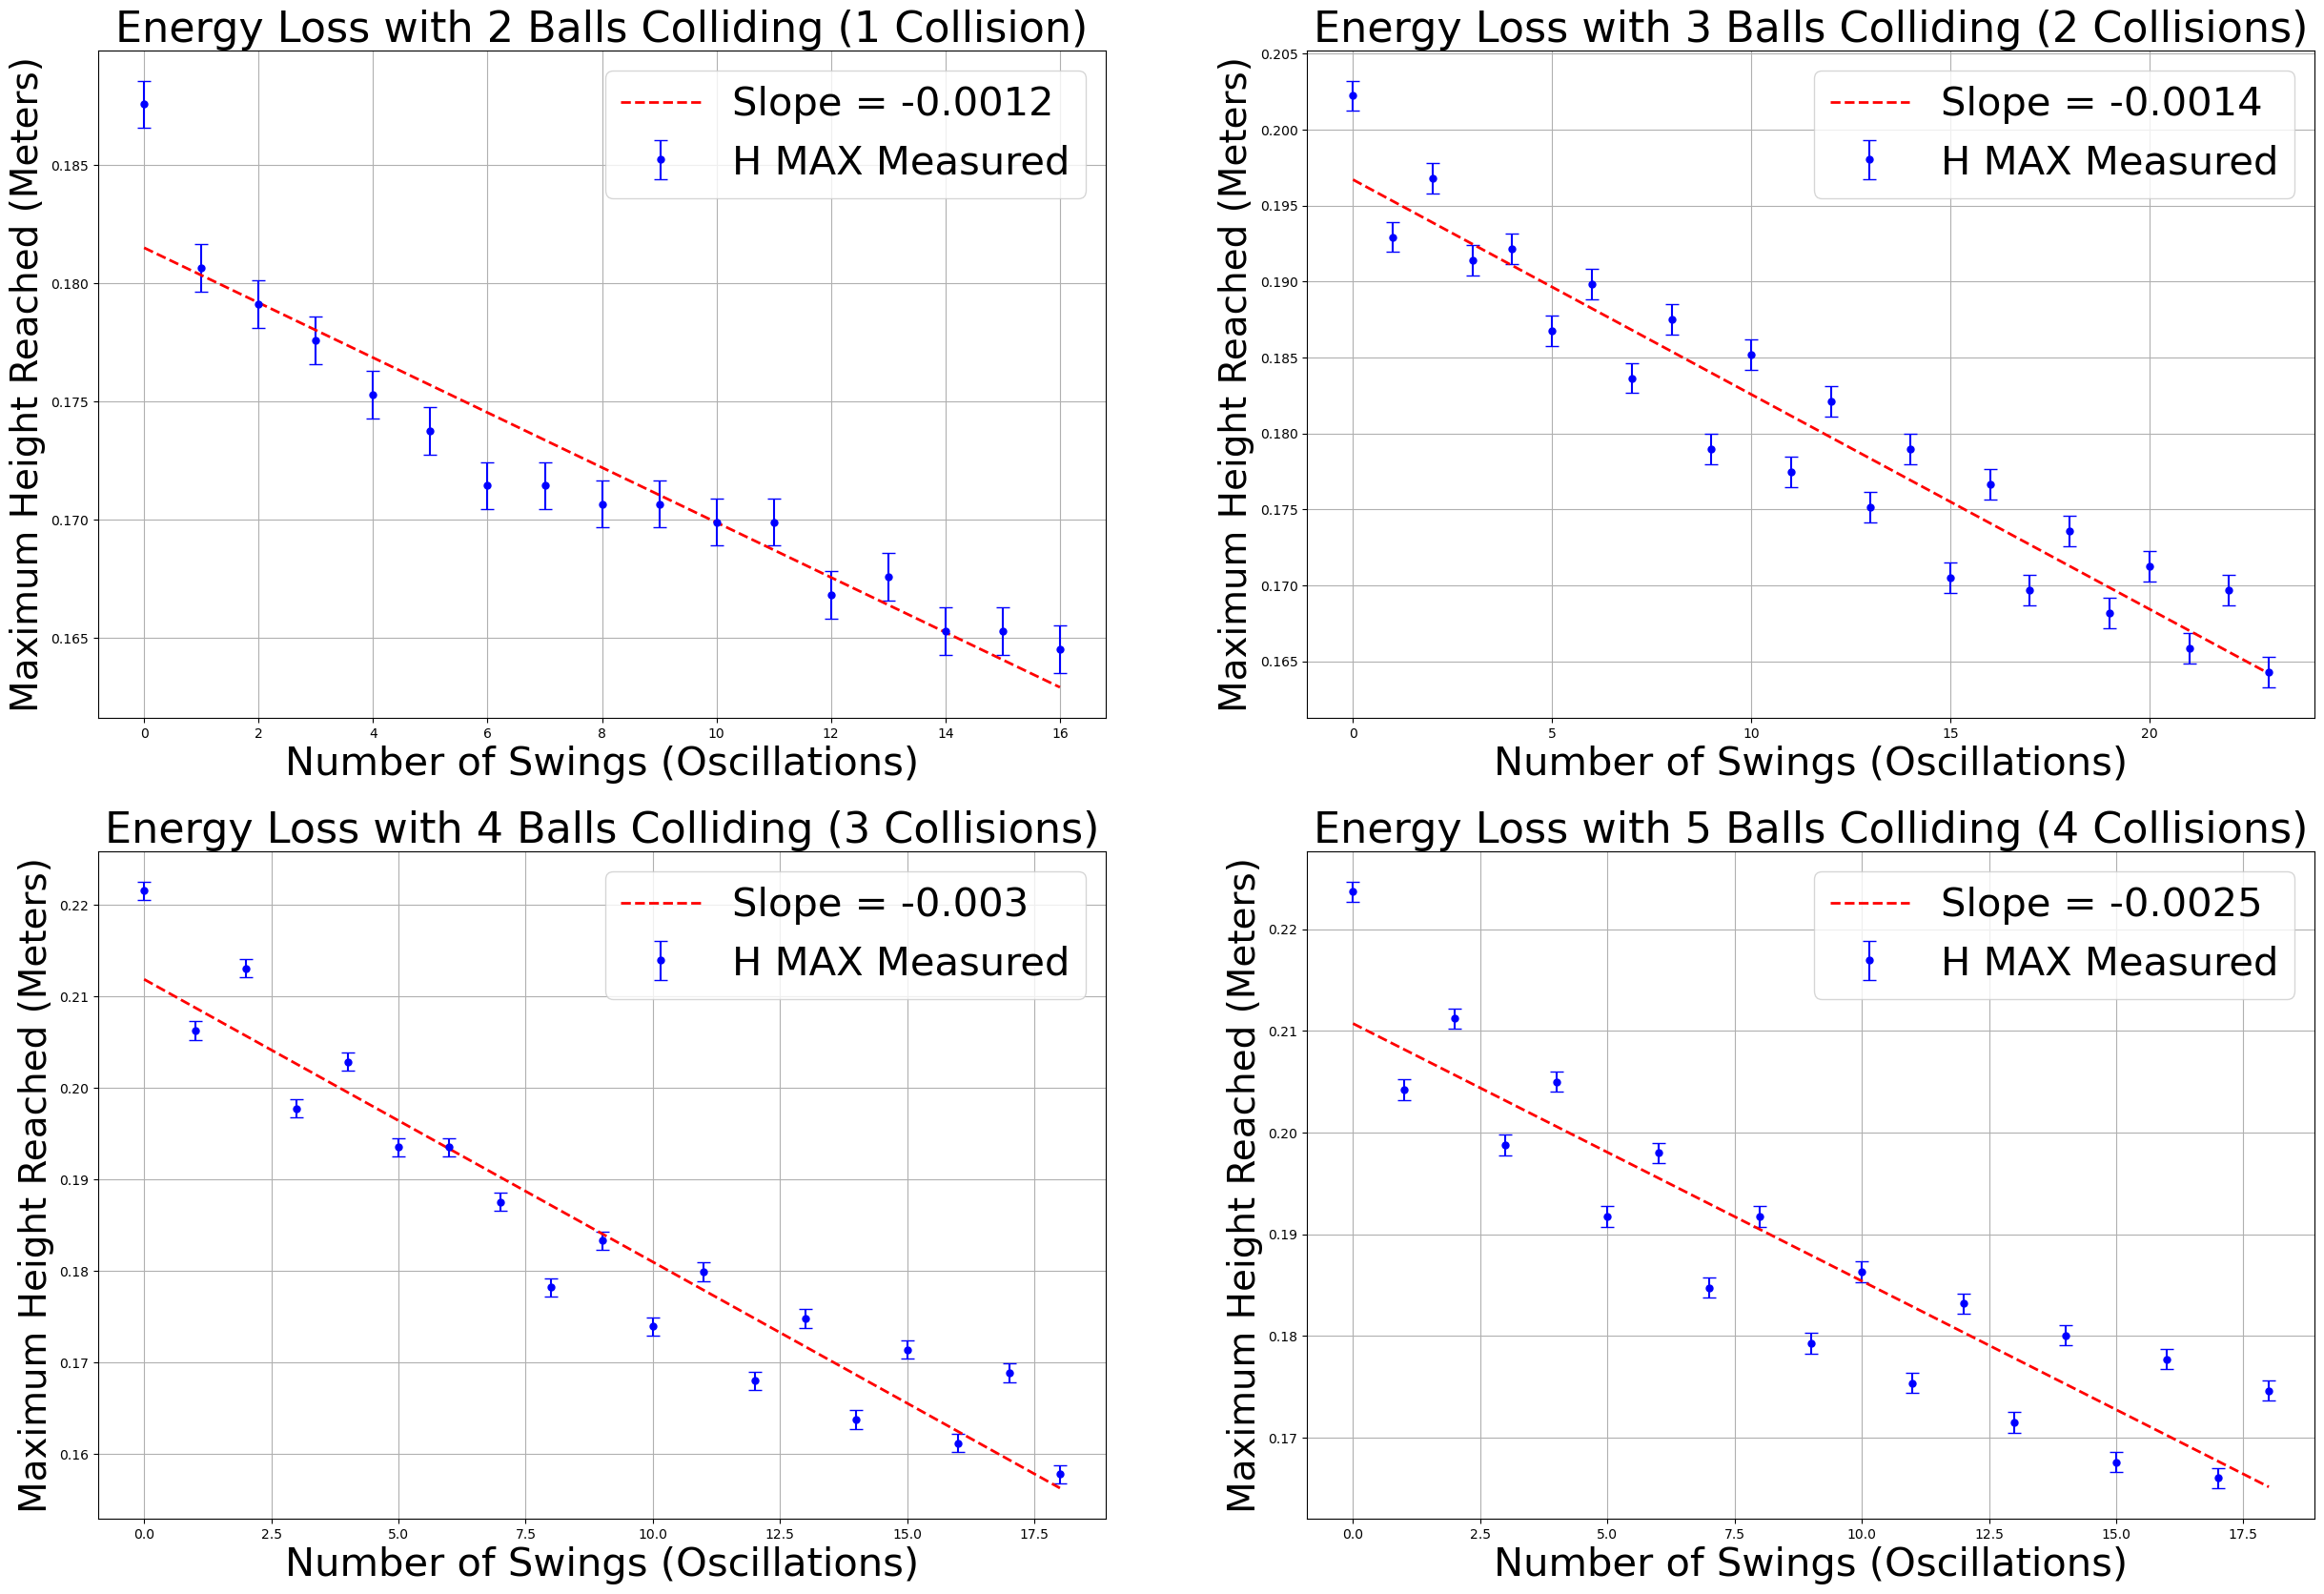

In [149]:
fig, axs = plt.subplots(2, 2, figsize=(30, 20))  # 2 rows, 2 columns
# Error bar plot
axs[0, 0].errorbar(data2["Number of collisions"], data2["VideoAnalysis: Y (m)"], 
             yerr=data2["dY"], fmt='o', color='blue', 
             label='H MAX Measured', markersize=5, capsize=5)

# Model plot
axs[0, 0].plot(data2["Number of collisions"], 
         linear_model(data2["Number of collisions"], intercept_2, slope_2), 
         color='red', linestyle='--', label=f'Slope = {slope_2:.2g}', linewidth=2)

# Title and labels
axs[0, 0].set_title("Energy Loss with 2 Balls Colliding (1 Collision)", fontsize=32)
axs[0, 0].set_xlabel("Number of Swings (Oscillations)", fontsize=30)
axs[0, 0].set_ylabel("Maximum Height Reached (Meters)", fontsize=28)
axs[0, 0].legend(fontsize=30)

# Grid
axs[0, 0].grid(True)

# Error bar plot
axs[0, 1].errorbar(data3["Number of collisions"], data3["VideoAnalysis: Y (m)"], 
             yerr=data3["dY"], fmt='o', color='blue', 
             label='H MAX Measured', markersize=5, capsize=5)

# Model plot
axs[0, 1].plot(data3["Number of collisions"], 
         linear_model(data3["Number of collisions"], intercept_3, slope_3), 
         color='red', linestyle='--', label=f'Slope = {slope_3:.2g}', linewidth=2)

# Title and labels
axs[0, 1].set_title("Energy Loss with 3 Balls Colliding (2 Collisions)", fontsize=32)
axs[0, 1].set_xlabel("Number of Swings (Oscillations)", fontsize=30)
axs[0, 1].set_ylabel("Maximum Height Reached (Meters)", fontsize=28)
axs[0, 1].legend(fontsize=30)

# Grid
axs[0, 1].grid(True)

# Error bar plot
axs[1, 0].errorbar(data4["Number of collisions"], data4["VideoAnalysis: Y (m)"], 
             yerr=data4["dY"], fmt='o', color='blue', 
             label='H MAX Measured', markersize=5, capsize=5)

# Model plot
axs[1, 0].plot(data4["Number of collisions"], 
         linear_model(data4["Number of collisions"], intercept_4, slope_4), 
         color='red', linestyle='--', label=f'Slope = {slope_4:.1g}', linewidth=2)

# Title and labels
axs[1, 0].set_title("Energy Loss with 4 Balls Colliding (3 Collisions)", fontsize=32)
axs[1, 0].set_xlabel("Number of Swings (Oscillations)", fontsize=30)
axs[1, 0].set_ylabel("Maximum Height Reached (Meters)", fontsize=28)

# Legend
axs[1, 0].legend(fontsize=30)

# Grid
axs[1, 0].grid(True)

# Error bar plot
axs[1, 1].errorbar(data5["Number of collisions"], data5["VideoAnalysis: Y (m)"], 
             yerr=data5["dY"], fmt='o', color='blue', 
             label='H MAX Measured', markersize=5, capsize=5)

# Model plot
axs[1, 1].plot(data5["Number of collisions"], 
         linear_model(data5["Number of collisions"], intercept_5, slope_5), 
         color='red', linestyle='--', label=f'Slope = {slope_5:.2g}', linewidth=2)

# Title and labels
axs[1, 1].set_title("Energy Loss with 5 Balls Colliding (4 Collisions)", fontsize=32)
axs[1, 1].set_xlabel("Number of Swings (Oscillations)", fontsize=30)
axs[1, 1].set_ylabel("Maximum Height Reached (Meters)", fontsize=28)

# Legend
axs[1, 1].legend(fontsize=30)

# Grid
axs[1, 1].grid(True)





# Error bar plot
axs[1, 1].errorbar(data5["Number of collisions"], data5["VideoAnalysis: Y (m)"], 
             yerr=data5["dY"], fmt='o', color='blue', 
             label='Height Measure', markersize=5, capsize=5)

# Model plot
axs[1, 1].plot(data5["Number of collisions"], 
         linear_model(data5["Number of collisions"], intercept_5, slope_5), 
         color='red', linestyle='--', label=f'Slope = {slope_5:.2g}', linewidth=2)

# Title and labels
axs[1, 1].set_title("Energy Lost With 4 Collisions", fontsize=16)
axs[1, 1].set_xlabel("Number of Swings", fontsize=14)
axs[1, 1].set_ylabel("Height Reached (Meters)", fontsize=14)

# Legend
axs[1, 1].legend(fontsize=12, loc='upper right')

# Grid
axs[1, 1].grid(True)



$$
\text{Model Energy Loss} = 6.23 \times 10^{-4} \left( \frac{\text{meter}}{\text{oscillation}} \right) \text{ per ball}
$$

## Error Estimates

### General Formula
$$
\delta y = \sqrt{\sum \left(\text{partial derivatives of variables} \times \text{uncertainty}\right)^2}
$$
}
\]

### Implementation
For each trial, an uncerta$$ty of \(\delta y = 0.001 \, $$ext{m}\) was applied consistently to account for measurement variability and observational error in LoggerPro.



### Implementation
For each trial, an uncertainty of $$\delta y = 0.001 \, \text{m}$$ was applied consistently to account for measurement variability and observational error in LoggerPro.

### Error Propagation

For a linear function \( y = mx + b \), the uncertainties in the slope \( m \) and intercept \( b \) propagate as follows:

$$
\delta y = \sqrt{\left( \frac{\partial y}{\partial m} \delta m \right)^2 + \left( \frac{\partial y}{\partial b} \delta b \right)^2}
$$

Where:
$$
\frac{\partial y}{\partial m} = x \quad \text{(sensitivity to \( m \))}
$$
$$
\frac{\partial y}{\partial b} = 1 \quad \text{(sensitivity to \( b \))}
$$

Therefore, the propagated uncertainty in \( y \) becomes:

$$
\delta y = \sqrt{(x \delta m)^2 + (\delta b)^2}
$$

### **Key Findings**

1. **Energy Loss Behavior**:
   The rate of energy dissipation (\( \Delta h / \text{oscillation} \)) generally increased with the number of colliding balls. The slope values of linear regression for energy loss were as follows:

   $$
   \begin{aligned}
   &\text{1 ball:} \, -0.000232 \pm 0.0001 \, \text{m/swing} \\
   &\text{2 balls:} \, -0.00116 \pm 0.0001 \, \text{m/swing} \\
   &\text{3 balls:} \, -0.00141 \pm 0.0001 \, \text{m/swing} \\
   &\text{4 balls:} \, -0.00309 \pm 0.0001 \, \text{m/swing} \\
   &\text{5 balls:} \, -0.00253 \pm 0.0001 \, \text{m/swing}
   \end{aligned}
   $$

2. **linear Trend**:
   Energy loss increased steadily up to 4 balls but showed a slight decrease in slope for 5 balls, possibly due to experimental uncertainties or diminishing effects of additional collisions.
